In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Rescaling
from tensorflow.keras.optimizers import Adam
import os
import numpy as np
import matplotlib.pyplot as plt 

In [30]:
data_path = r'C:\Users\User\OneDrive\Desktop\AIML\outputs\outputs'

In [31]:
categories = os.listdir(data_path)
print(categories)

['Disappointed', 'Interested', 'Neutral']


In [32]:
# --- Define the Parameters ---

In [33]:
img_height = 50
img_width = 50

img_size = (img_height, img_width)
b_size = 64

In [34]:
print("Loading training data....")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = img_size,
    batch_size = b_size,
    color_mode = 'grayscale'
)

Loading training data....
Found 34395 files belonging to 3 classes.
Using 27516 files for training.


In [35]:
print("Loading validation data...")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = img_size,
    batch_size = b_size,
    color_mode = 'grayscale'
)

Loading validation data...
Found 34395 files belonging to 3 classes.
Using 6879 files for validation.


In [36]:
class_names = train_dataset.class_names
print(f"Found class names: {class_names}")

Found class names: ['Disappointed', 'Interested', 'Neutral']


In [37]:
# --- DEFINE THE CNN MODEL ---

In [38]:
model = Sequential([
    Input(shape=(img_height, img_width, 1)),
    
    Rescaling(1./255), 
    
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dense(100, activation='relu'),
    Dense(50,  activation='relu'),
    Dense(3, activation='softmax')
])

In [39]:
# --- COMPILE THE MODEL ---

In [40]:
model.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [41]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)              │ (None, 50, 50, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 50, 50, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 50, 50, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 25, 25, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 25, 25, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 25, 25, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 100)                 │          12,900 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 3)                   │             153 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 701,623 (2.68 MB)

 Trainable params: 701,175 (2.67 MB)

 Non-trainable params: 448 (1.75 KB)

In [42]:
# --- TRAIN THE MODEL ---

In [43]:
print("\nStarting model training....")

history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 20
)

print("\nTraining complete...")


Starting model training....
Epoch 1/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 53s 119ms/step - accuracy: 0.5203 - loss: 0.9625 - val_accuracy: 0.3426 - val_loss: 1.3231
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 52s 121ms/step - accuracy: 0.6011 - loss: 0.8323 - val_accuracy: 0.6039 - val_loss: 0.8231
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 48s 112ms/step - accuracy: 0.6468 - loss: 0.7558 - val_accuracy: 0.6223 - val_loss: 0.7943
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 54s 126ms/step - accuracy: 0.6869 - loss: 0.6906 - val_accuracy: 0.6417 - val_loss: 0.7868
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 50s 116ms/step - accuracy: 0.7287 - loss: 0.6112 - val_accuracy: 0.5966 - val_loss: 0.8621
Epoch 6/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 51s 118ms/step - accuracy: 0.7751 - loss: 0.5243 - val_accuracy: 0.6193 - val_loss: 0.9868
Epoch 7/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 49s 114ms/step - accuracy: 0.8204 - loss: 0.4324 - val_accuracy: 0.6207 - val_loss: 1.1125
Epoch 8/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 48s 111ms/step


Evaluating model on validation data....
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.5988 - loss: 1.9943
Final Validation Accuracy: 59.88%


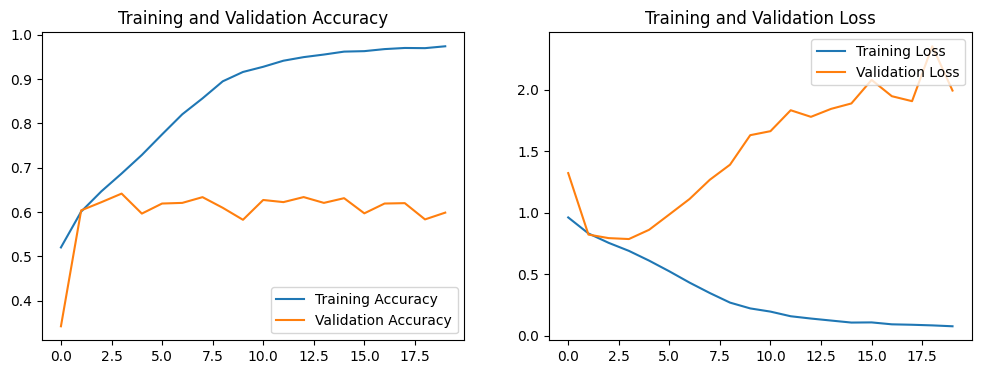

In [44]:
print("\nEvaluating model on validation data....")
loss, accuracy = model.evaluate(validation_dataset)
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")


# Plot the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(20)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# ------------ The Classification Report ------------

In [ ]:
print("Gathering predictions from validation set...")
y_pred = [] 
y_true = []

for images, labels in validation_dataset:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("Predictions gathered...")

print("Classification Report")
print("---" * 10)

print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
# ------------ The Confusion Matrix ------------

In [ ]:
print("Generating Confusion Matrix...")
print("---" * 10)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel('Actual (True) Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()